# PyTorch 回归实战——自定义全连接层（CustomizedLinear）

## 1. 环境初始化与依赖导入

In [ ]:
import matplotlib as mpl            # 导入 matplotlib 绘图库核心模块
import matplotlib.pyplot as plt     # 导入 pyplot 子模块，用于绘图
%matplotlib inline                 
# Jupyter 魔法命令：将图表嵌入 Notebook 中显示
import numpy as np                  # 导入 NumPy 数值计算库，用于数组与矩阵运算
import sklearn                       # 导入 scikit-learn 机器学习库
import pandas as pd                 # 导入 Pandas 数据分析库
import os                             # 导入操作系统接口模块
import sys                            # 导入系统模块，用于获取 Python 版本信息
import time                           # 导入时间模块
from tqdm import tqdm            # 导入 tqdm 进度条库；auto 版本自动适配显示环境
import torch                          # 导入 PyTorch 深度学习框架
import torch.nn as nn                 # 导入神经网络模块，包含各种预定义层和容器
import torch.nn.functional as F       # 导入函数式 API

# 打印环境版本信息
print(sys.version_info)               # 输出 Python 版本详细信息
for module in mpl, np, pd, sklearn, torch:    # 遍历各主要依赖库
    print(module.__name__, module.__version__) # 打印库名与版本号

# 设备选择：优先使用 GPU（CUDA），否则使用 CPU
device = torch.device('cuda:0') if torch.cuda.is_available() else torch.device('cpu')  # 返回 torch.device
print(device)  # 输出当前计算设备

sys.version_info(major=3, minor=12, micro=3, releaselevel='final', serial=0)
matplotlib 3.10.0
numpy 1.26.4
pandas 2.2.3
sklearn 1.6.0
torch 2.5.1+cpu
cpu


## 2. 准备数据

### 2.1 加载加州房价数据集

In [ ]:
from sklearn.datasets import fetch_california_housing  # 导入加州房价数据集加载函数

# fetch_california_housing() 返回 Bunch 对象，包含 data、target、DESCR 等字段
housing = fetch_california_housing()  # 加载数据集
print(housing.DESCR)           # 打印数据集完整描述（特征名称、样本数量等）
print(housing.data.shape)      # 特征矩阵形状：(20640, 8)，共 8 个预测特征
print(housing.target.shape)    # 目标值形状：(20640,)，房价中位数（单位：$100,000）

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per ce

In [ ]:
import pprint  # 导入 pprint 模块，格式化打印复杂数据结构

# 预览前 5 个样本的原始特征数据和目标值
pprint.pprint(housing.data[0:5])    # 打印前 5 个样本的 8 维特征向量
print('-' * 50)                      # 打印分隔线
pprint.pprint(housing.target[0:5])  # 打印前 5 个样本的目标房价中位数

array([[ 8.32520000e+00,  4.10000000e+01,  6.98412698e+00,
         1.02380952e+00,  3.22000000e+02,  2.55555556e+00,
         3.78800000e+01, -1.22230000e+02],
       [ 8.30140000e+00,  2.10000000e+01,  6.23813708e+00,
         9.71880492e-01,  2.40100000e+03,  2.10984183e+00,
         3.78600000e+01, -1.22220000e+02],
       [ 7.25740000e+00,  5.20000000e+01,  8.28813559e+00,
         1.07344633e+00,  4.96000000e+02,  2.80225989e+00,
         3.78500000e+01, -1.22240000e+02],
       [ 5.64310000e+00,  5.20000000e+01,  5.81735160e+00,
         1.07305936e+00,  5.58000000e+02,  2.54794521e+00,
         3.78500000e+01, -1.22250000e+02],
       [ 3.84620000e+00,  5.20000000e+01,  6.28185328e+00,
         1.08108108e+00,  5.65000000e+02,  2.18146718e+00,
         3.78500000e+01, -1.22250000e+02]])
--------------------------------------------------
array([4.526, 3.585, 3.521, 3.413, 3.422])


### 2.2 数据集划分（训练集 / 验证集 / 测试集）

In [ ]:
from sklearn.model_selection import train_test_split  # 导入数据集划分工具

# 第一次划分：全量数据 → 训练+验证集（75%）和测试集（25%）
x_train_all, x_test, y_train_all, y_test = train_test_split(
    housing.data, housing.target, random_state=7)  # random_state 固定随机种子

# 第二次划分：训练+验证集 → 训练集（75%）和验证集（25%）
x_train, x_valid, y_train, y_valid = train_test_split(
    x_train_all, y_train_all, random_state=11)

print(x_train.shape, y_train.shape)   # 训练集：(11610, 8) (11610,)
print(x_valid.shape, y_valid.shape)   # 验证集：(3870, 8) (3870,)
print(x_test.shape,  y_test.shape)    # 测试集：(5160, 8) (5160,)

# 将三个数据集存入字典，便于 HousingDataset 按 mode 统一读取
dataset_maps = {
    'train': [x_train, y_train],  # 训练集
    'valid': [x_valid, y_valid],  # 验证集
    'test':  [x_test,  y_test],   # 测试集
}

(11610, 8) (11610,)
(3870, 8) (3870,)
(5160, 8) (5160,)


### 2.3 特征标准化（StandardScaler）

In [ ]:
from sklearn.preprocessing import StandardScaler  # 导入标准化工具
from torch.utils.data import DataLoader            # 导入数据加载器（后续使用）

# 标准化：消除特征量纲差异，加快模型收敛
scaler = StandardScaler()  # 实例化 StandardScaler
scaler.fit(x_train)        # 仅在训练集上拟合均值和标准差，防止数据泄露；返回 fitted scaler

StandardScaler()

### 2.4 自定义 Dataset 类

In [ ]:
from torch.utils.data import Dataset  # 导入 Dataset 抽象基类

class HousingDataset(Dataset):
    """
    加州房价自定义数据集类，继承 torch.utils.data.Dataset。
    必须实现 __len__ 和 __getitem__ 方法供 DataLoader 调用。
    """
    def __init__(self, mode='train'):
        """初始化数据集
        参数:
            mode (str): 数据集模式，可选 'train'、'valid'、'test'
        """
        self.x, self.y = dataset_maps[mode]  # 按 mode 从字典获取对应数据
        self.x = torch.from_numpy(scaler.transform(self.x)).float()  # 标准化后转为 float32 Tensor，shape:[N,8]
        self.y = torch.from_numpy(self.y).float().reshape(-1, 1)     # 标签转为列向量 Tensor，shape:[N,1]

    def __len__(self):
        """返回样本总数；DataLoader 用此确定 batch 数量"""
        return len(self.x)

    def __getitem__(self, idx):
        """按索引返回单个样本
        参数:
            idx (int): 样本索引
        返回值:
            tuple: (特征 Tensor[8], 标签 Tensor[1])
        """
        return self.x[idx], self.y[idx]


# 实例化三个数据集对象
train_ds = HousingDataset('train')  # 训练集，11610 个样本
valid_ds = HousingDataset('valid')  # 验证集，3870 个样本
test_ds  = HousingDataset('test')   # 测试集，5160 个样本

In [ ]:
train_ds[1]  # 预览第 1 个训练样本；返回 tuple：(特征 Tensor[8], 标签 Tensor[1])

(tensor([-0.2981,  0.3523, -0.1092, -0.2506, -0.0341, -0.0060,  1.0806, -1.0611]),
 tensor([1.5140]))

### 2.5 构建 DataLoader

In [ ]:
from torch.utils.data import DataLoader  # 导入数据加载器

# batch_size=256：每个 mini-batch 含 256 个样本
# 较大的 batch_size 可提高 GPU 利用率，但对内存要求更高；梯度估计更准确但更新频率降低
batch_size = 256

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)   # 训练集：每 epoch 打乱顺序
val_loader   = DataLoader(valid_ds, batch_size=batch_size, shuffle=False)  # 验证集：顺序加载
test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False)  # 测试集：顺序加载

## 3. 定义神经网络模型

### 3.1 自定义全连接层（CustomizedLinear）

本节核心：手动实现全连接层（代替内置的 `nn.Linear`），演示如何：
- 使用 `nn.Parameter` 定义可学习参数
- 使用 `nn.init` 进行参数初始化
- 在 `forward()` 中实现线性变换 $y = xW + b$

In [ ]:
class CustomizedLinear(nn.Module):
    """
    自定义全连接层，功能等价于 nn.Linear。
    演示如何手动定义可学习参数并实现前向传播。
    """
    def __init__(self, in_features, out_features):
        """初始化自定义全连接层
        参数:
            in_features  (int): 输入特征维度
            out_features (int): 输出特征维度
        """
        super().__init__()  # 调用父类 nn.Module 的 __init__
        # nn.Parameter：将 Tensor 注册为模型的可学习参数（自动参与梯度计算和优化器更新）
        # 权重矩阵 W，shape=[in_features, out_features]，初始为全 0
        self.weights = nn.Parameter(torch.zeros(in_features, out_features))
        # xavier_normal_ 初始化：根据输入/输出维度自动计算方差，有助于梯度稳定传播
        # 带 _ 后缀的方法为原地操作，直接修改 self.weights 的数值
        self.weights = nn.init.xavier_normal_(self.weights)
        # 偏置向量 b，shape=[out_features]，初始为全 0
        # nn.Parameter 确保偏置也参与梯度计算和优化
        self.bias = nn.Parameter(torch.zeros(out_features))

    def forward(self, x):
        """前向传播：实现线性变换 y = x @ W + b
        参数:
            x (Tensor): 输入张量，shape=[batch_size, in_features]
        返回值:
            Tensor: 输出张量，shape=[batch_size, out_features]
        """
        return torch.mm(x, self.weights) + self.bias  # torch.mm：矩阵乘法；+ self.bias 利用广播加偏置

### 3.2 使用 CustomizedLinear 构建神经网络

In [ ]:
# 使用自定义全连接层替换内置 nn.Linear，构建相同架构的神经网络
class NeuralNetwork(nn.Module):
    """
    使用 CustomizedLinear 的两层神经网络，用于加州房价回归预测
    网络结构：CustomizedLinear(8→30) → ReLU → CustomizedLinear(30→1)
    """
    def __init__(self, input_dim=8):
        """初始化网络结构
        参数:
            input_dim (int): 输入特征维度，默认 8
        """
        super().__init__()  # 调用父类初始化
        self.linear_relu_stack = nn.Sequential(
            CustomizedLinear(input_dim, 30),  # 自定义全连接层：8 → 30
            nn.ReLU(),                         # ReLU 激活函数：引入非线性
            CustomizedLinear(30, 1)             # 自定义全连接层：30 → 1（回归输出）
        )

    def forward(self, x):
        """前向传播
        参数:
            x (Tensor): 输入特征，shape=[batch_size, 8]
        返回值:
            logits (Tensor): 预测输出，shape=[batch_size, 1]
        """
        logits = self.linear_relu_stack(x)  # 顺序通过各层
        return logits

### 3.3 查看模型参数

In [ ]:
model = NeuralNetwork()  # 实例化神经网络
# named_parameters() 返回迭代器，每个元素为 (参数名, 参数 Tensor) 的二元组
for name, param in model.named_parameters():  # 遍历所有可学习参数
    print(name, param.shape)  # 打印参数名称和形状（shape 为 torch.Size 对象）

linear_relu_stack.0.weights torch.Size([8, 30])
linear_relu_stack.0.bias torch.Size([30])
linear_relu_stack.2.weights torch.Size([30, 1])
linear_relu_stack.2.bias torch.Size([1])


In [ ]:
# 计算模型总参数量，评估模型复杂度
# p.numel()：返回参数 p 中的元素总数（int）
total_params = sum(p.numel() for p in NeuralNetwork().parameters())  # 遍历所有参数并累加元素数
print(f'Total number of parameters: {total_params:,}')  # 格式化输出，千位分隔符便于阅读

Total number of parameters: 301


In [ ]:
# model.modules() 返回所有子模块（包括自身）的迭代器，用于查看网络层级结构
for m in model.modules():  # 遍历模型的所有模块（自顶向下，包含嵌套模块）
    print(m)            # 打印每个模块的类型及其配置信息
    print('-' * 50)     # 打印分隔线

NeuralNetwork(
  (linear_relu_stack): Sequential(
    (0): CustomizedLinear()
    (1): ReLU()
    (2): CustomizedLinear()
  )
)
--------------------------------------------------
Sequential(
  (0): CustomizedLinear()
  (1): ReLU()
  (2): CustomizedLinear()
)
--------------------------------------------------
CustomizedLinear()
--------------------------------------------------
ReLU()
--------------------------------------------------
CustomizedLinear()
--------------------------------------------------


## 4. 训练辅助工具

### 4.1 早停机制（EarlyStopCallback）

In [ ]:
class EarlyStopCallback:
    """
    早停回调类：当监控指标在连续 patience 次评估中无显著改善时，停止训练，防止过拟合。
    """
    def __init__(self, patience=5, min_delta=0.01):
        """初始化早停参数
        参数:
            patience  (int):   允许连续无改善的最大评估次数，超过则触发早停；默认 5
            min_delta (float): 判定为改善的最小变化量；小于此值视为无改善；默认 0.01
        """
        self.patience    = patience   # 耐心值
        self.min_delta   = min_delta  # 最小改善阈值
        self.best_metric = -1         # 历史最优指标（初始为极小值）
        self.counter     = 0          # 连续无改善计数器

    def __call__(self, metric):
        """每次评估后调用，传入当前指标（越大越好）"""
        if metric >= self.best_metric + self.min_delta:  # 有显著改善
            self.best_metric = metric  # 更新最优指标
            self.counter = 0            # 重置计数器
        else:
            self.counter += 1  # 无改善，计数器加 1

    @property
    def early_stop(self):
        """判断是否触发早停；返回 bool"""
        return self.counter >= self.patience  # 达到耐心值时返回 True

### 4.2 验证集评估函数

In [ ]:
from sklearn.metrics import accuracy_score  # 导入准确率评估函数（分类任务常用，本例保留导入）

@torch.no_grad()  # 关闭梯度计算，节省显存和计算资源（评估阶段不需要反向传播）
def evaluating(model, dataloader, loss_fct):
    """在指定 dataloader 上计算模型平均损失
    参数:
        model      (nn.Module)  : 待评估的神经网络
        dataloader (DataLoader) : 数据加载器
        loss_fct               : 损失函数
    返回值:
        float：所有 batch 损失的均值
    """
    loss_list = []  # 存储每个 batch 的损失值
    for datas, labels in dataloader:   # 遍历每个 batch
        datas  = datas.to(device)       # 特征迁移到目标设备
        labels = labels.to(device)      # 标签迁移到目标设备
        logits = model(datas)            # 前向计算得预测值
        loss   = loss_fct(logits, labels)  # 计算 batch 损失
        loss_list.append(loss.item())      # 提取为 Python float

    return np.mean(loss_list)  # 返回所有 batch 的平均损失（float）

## 5. 模型训练

In [ ]:
# ──────────────────────────────────────────────────────
# 训练主函数
# ──────────────────────────────────────────────────────
def training(
    model,                      # 待训练的神经网络（nn.Module 子类）
    train_loader,               # 训练集 DataLoader
    val_loader,                 # 验证集 DataLoader
    epoch,                      # 最大训练轮数
    loss_fct,                   # 损失函数
    optimizer,                  # 优化器
    tensorboard_callback=None,  # TensorBoard 回调（本例未使用）
    save_ckpt_callback=None,    # 检查点保存回调（本例未使用）
    early_stop_callback=None,   # 早停回调
    eval_step=500,              # 每隔多少步进行一次验证
    ):
    record_dict = {'train': [], 'val': []}  # 损失历史记录字典

    global_step = 0   # 全局步数（跨 epoch 累计）
    model.train()     # 切换为训练模式

    with tqdm(total=epoch * len(train_loader)) as pbar:  # 初始化进度条
        for epoch_id in range(epoch):            # 遍历每个 epoch
            for datas, labels in train_loader:    # 遍历每个 mini-batch
                datas  = datas.to(device)          # 特征迁移到目标设备
                labels = labels.to(device)         # 标签迁移到目标设备

                optimizer.zero_grad()              # 清零梯度
                logits = model(datas)               # 前向传播得预测值
                loss   = loss_fct(logits, labels)   # 计算训练损失
                loss.backward()                    # 反向传播计算梯度
                optimizer.step()                   # 优化器更新参数

                loss = loss.cpu().item()            # 转为 Python float
                record_dict['train'].append({'loss': loss, 'step': global_step})  # 记录训练损失

                if global_step % eval_step == 0:   # 每隔 eval_step 步评估一次
                    model.eval()  # 切换为评估模式
                    val_loss = evaluating(model, val_loader, loss_fct)  # 计算验证损失
                    record_dict['val'].append({'loss': val_loss, 'step': global_step})
                    model.train()  # 恢复训练模式

                    if early_stop_callback is not None:
                        early_stop_callback(-val_loss)        # 传入负损失（越小越好→负值越大越好）
                        if early_stop_callback.early_stop:    # 触发早停
                            print(f'Early stop at epoch {epoch_id} / global_step {global_step}')
                            return record_dict

                global_step += 1          # 全局步数加 1
                pbar.update(1)            # 进度条前进 1 步
                pbar.set_postfix({'epoch': epoch_id})  # 显示当前 epoch 编号

    return record_dict


# ──────────────────────────────────────────────────────
# 配置超参数并启动训练
# ──────────────────────────────────────────────────────
epoch = 100  # 最大训练轮数

model = NeuralNetwork()  # 使用含 CustomizedLinear 的神经网络

# 1. 损失函数：使用 PyTorch 内置 MSE 损失（与第 2 章自定义版本对比）
loss_fct = nn.MSELoss()  # nn.MSELoss() 实例化均方误差损失；reduction='mean'（默认）

# 2. 优化器：SGD，动量 0.9
optimizer = torch.optim.SGD(model.parameters(), lr=0.001, momentum=0.9)

# 3. 早停：连续 10 次评估无改善则停止
early_stop_callback = EarlyStopCallback(patience=10, min_delta=1e-3)

model = model.to(device)  # 将模型迁移到目标设备

record = training(
    model, train_loader, val_loader, epoch, loss_fct, optimizer,
    early_stop_callback=early_stop_callback,
    eval_step=len(train_loader),  # 每个 epoch 末进行一次验证
)

  0%|          | 0/4600 [00:00<?, ?it/s]

## 6. 可视化学习曲线

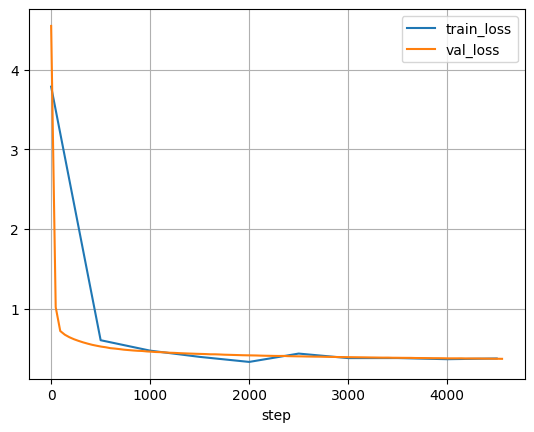

In [ ]:
# 绘制训练集与验证集损失曲线，分析模型收敛情况
def plot_learning_curves(record_dict, sample_step=500):
    """绘制训练和验证损失曲线
    参数:
        record_dict (dict): 损失历史字典，含 'train' 和 'val' 两个键
        sample_step (int) : 训练集损失采样间隔；默认 500
    """
    # 训练集损失转 DataFrame，以 step 为索引，每隔 sample_step 采样一次
    train_df = pd.DataFrame(record_dict['train']).set_index('step').iloc[::sample_step]
    # 验证集损失转 DataFrame（记录较少，全部显示）
    val_df   = pd.DataFrame(record_dict['val']).set_index('step')

    for idx, item in enumerate(train_df.columns):  # 遍历每个指标列
        plt.plot(train_df.index, train_df[item], label=f'train_{item}')  # 训练集损失曲线
        plt.plot(val_df.index,   val_df[item],   label=f'val_{item}')    # 验证集损失曲线
        plt.grid()    # 添加网格线
        plt.legend()  # 显示图例
        plt.xlabel('step')  # 横坐标：全局步数
        plt.show()    # 展示图形

plot_learning_curves(record)  # 横坐标为全局步数（steps）

## 7. 测试集评估

In [ ]:
model.eval()  # 切换模型为评估模式
loss = evaluating(model, val_loader, loss_fct)  # 在验证集上计算平均 MSE 损失
print(f'loss:     {loss:.4f}')  # 打印格式化损失值，保留 4 位小数

loss:     0.3687
